In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

print("Upload your latest drug_reviews_clean_*.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

print(f"Uploaded file: {filename}")

Upload your latest drug_reviews_clean_*.csv


Saving drug_reviews_imputed_rf.csv to drug_reviews_imputed_rf (1).csv
 Uploaded file: drug_reviews_imputed_rf (1).csv


In [ ]:
import os
import pandas as pd

# Create folder
os.makedirs("src/data", exist_ok=True)

# Load your uploaded file and save to correct path
df = pd.read_csv(filename)  # This is the uploaded file
df.to_csv("src/data/combined_dataset.csv", index=False)

print(" Dataset saved to src/data/combined_dataset.csv")

 Dataset saved to src/data/combined_dataset.csv


In [ ]:
# Fix column names if needed
df = pd.read_csv("src/data/combined_dataset.csv")

if 'drug_review' in df.columns:
    df = df.rename(columns={'drug_review': 'review_text'})
if 'drugName' in df.columns and 'drug_name' not in df.columns:
     df = df.rename(columns={'drugName': 'drug_name'})

# Keep necessary columns, including 'drug_name'
df = df[['drug_name', 'review_text', 'age', 'gender']].dropna(subset=['review_text'])

df.to_csv("src/data/combined_dataset.csv", index=False)
print("Column names fixed and unnecessary columns removed")

Column names fixed and unnecessary columns removed


In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

In [ ]:
!pip install nlpaug nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.4 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import joblib
import nlpaug.augmenter.word as naw
from torch import nn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# -----------------------------
# 1. Load and Label Data
# -----------------------------
df = pd.read_csv("/content/src/data/combined_dataset.csv")
if 'review' in df.columns:
    df = df.rename(columns={'review': 'review_text'})
df = df.dropna(subset=['review_text'])

def classify_review_category(text):
    # FIX: Normalize text (handles curly vs straight apostrophes)
    text = text.lower().replace("’", "'")

    # Expanded keyword lists for better coverage
    positive_kw = ['helped', 'working', 'effective', 'relief', 'improved', 'better', 'great', 'life changing', 'happy']
    ineffective_kw = ['not work', 'no effect', 'useless', 'ineffective', 'waste of money', 'nothing happened', 'did nothing']
    dependency_kw = ['addicted', 'withdrawal', 'can\'t stop', 'dependent', 'shakes', 'craving', 'addiction']
    dosage_kw = ['dosage', 'dose', 'too strong', 'too weak', '10mg', '20mg', '50mg', '100mg', 'mg', 'milligrams']
    side_effect_kw = ['nausea', 'vomit', 'dizzy', 'rash', 'insomnia', 'headache', 'tired', 'palpitations']

    if any(k in text for k in dependency_kw): return "Dependency/Addiction"
    if any(k in text for k in side_effect_kw):
        if any(k in text for k in positive_kw): return "Mixed_Feedback"
        return "Severe_Side_Effects"
    if any(k in text for k in dosage_kw): return "Dosage_Issues"
    if any(k in text for k in ineffective_kw): return "Ineffective"
    if any(k in text for k in positive_kw): return "Positive_Experience"
    return "Mixed_Feedback"

df['review_category'] = df['review_text'].apply(classify_review_category)

# -----------------------------
# 2. Data Augmentation (Balancing)
# -----------------------------
print("Augmenting minority classes...")
aug = naw.SynonymAug(aug_src='wordnet')

def augment_data(df, target_per_cat=500):
    balanced_dfs = []
    for cat in df['review_category'].unique():
        cat_df = df[df['review_category'] == cat]
        current_count = len(cat_df)

        if current_count < target_per_cat:
            needed = target_per_cat - current_count
            augmented_texts = []
            for i in range(needed):
                text = cat_df.iloc[i % current_count]['review_text']
                # Create a synonym-swapped version
                augmented_texts.append(aug.augment(text)[0])

            aug_df = pd.DataFrame({'review_text': augmented_texts, 'review_category': cat})
            cat_df = pd.concat([cat_df, aug_df])

        balanced_dfs.append(cat_df)
    return pd.concat(balanced_dfs).sample(frac=1).reset_index(drop=True)

df = augment_data(df, target_per_cat=500)
print(f"Dataset balanced. New distribution:\n{df['review_category'].value_counts()}")

# -----------------------------
# 3. Encoding and Splitting
# -----------------------------
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['review_category'])

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['review_text'].tolist(), df['label'].tolist(), test_size=0.2, stratify=df['label'], random_state=42
)

# -----------------------------
# 4. Weighted Loss Trainer
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# -----------------------------
# 5. Tokenizer & Dataset
# -----------------------------
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ReviewDataset(train_texts, train_labels, tokenizer)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer)

# -----------------------------
# 6. Training Execution
# -----------------------------
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=len(label_encoder.classes_)
).to(device)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True if torch.cuda.is_available() else False,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {"accuracy": (np.argmax(p.predictions, axis=-1) == p.label_ids).mean()}
)

print("Starting Final Training...")
trainer.train()

# -----------------------------
# 7. Save Model & Encoder
# -----------------------------
MODEL_DIR = "./models/fine_tuned_distilbert_drug_reviews(1)"
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
joblib.dump(label_encoder, f"{MODEL_DIR}/label_encoder.pkl")
print(f"Model successfully saved to {MODEL_DIR}")

Augmenting minority classes...
Dataset balanced. New distribution:
review_category
Mixed_Feedback          20590
Positive_Experience     10017
Dosage_Issues            6612
Severe_Side_Effects      5750
Dependency/Addiction     1781
Ineffective               830
Name: count, dtype: int64


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Final Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.159000,0.076187,0.994405
2,0.032400,0.019553,0.997806
3,0.010900,0.009809,0.998355
4,0.003200,0.007426,0.999122


Model successfully saved to ./models/fine_tuned_distilbert_drug_reviews(1)


In [ ]:
import torch
import joblib
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch.nn.functional as F

# 1. Path to your saved model
MODEL_PATH = "./models/fine_tuned_distilbert_drug_reviews(1)"

# 2. Load the components
print("Loading model and tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_PATH)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
label_encoder = joblib.load(f"{MODEL_PATH}/label_encoder.pkl")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set to evaluation mode

def predict_review(text):
    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        # Calculate probabilities
        probs = F.softmax(logits, dim=-1)
        conf, pred_idx = torch.max(probs, dim=-1)

    # Map index back to label name
    label = label_encoder.inverse_transform([pred_idx.item()])[0]
    return label, conf.item()

# -----------------------------
# 3. Test with Example Reviews
# -----------------------------
test_reviews = [
    "This medication changed my life, I feel so much better now!", # Likely Positive
    "I took it for a week but nothing happened, complete waste of money.", # Likely Ineffective
    "I can't stop taking this, I get shakes and headaches if I miss a day.", # Likely Dependency
    "I feel extremely dizzy and have a weird rash on my arm.", # Likely Side Effects
    "The doctor told me to take 10mg but I think it is too much for me." # Likely Dosage Issues
]

print("Model Predictions")
for review in test_reviews:
    label, confidence = predict_review(review)
    print(f"Review: {review}")
    print(f"Prediction: **{label}** ({confidence:.2%} confidence)")
    print("-" * 30)

Loading model and tokenizer...
Model Predictions
Review: This medication changed my life, I feel so much better now!
Prediction: **Positive_Experience** (100.00% confidence)
------------------------------
Review: I took it for a week but nothing happened, complete waste of money.
Prediction: **Ineffective** (99.99% confidence)
------------------------------
Review: I can't stop taking this, I get shakes and headaches if I miss a day.
Prediction: **Dependency/Addiction** (100.00% confidence)
------------------------------
Review: I feel extremely dizzy and have a weird rash on my arm.
Prediction: **Severe_Side_Effects** (99.99% confidence)
------------------------------
Review: The doctor told me to take 10mg but I think it is too much for me.
Prediction: **Dosage_Issues** (99.99% confidence)
------------------------------


Confusion Matrix - Test Data:


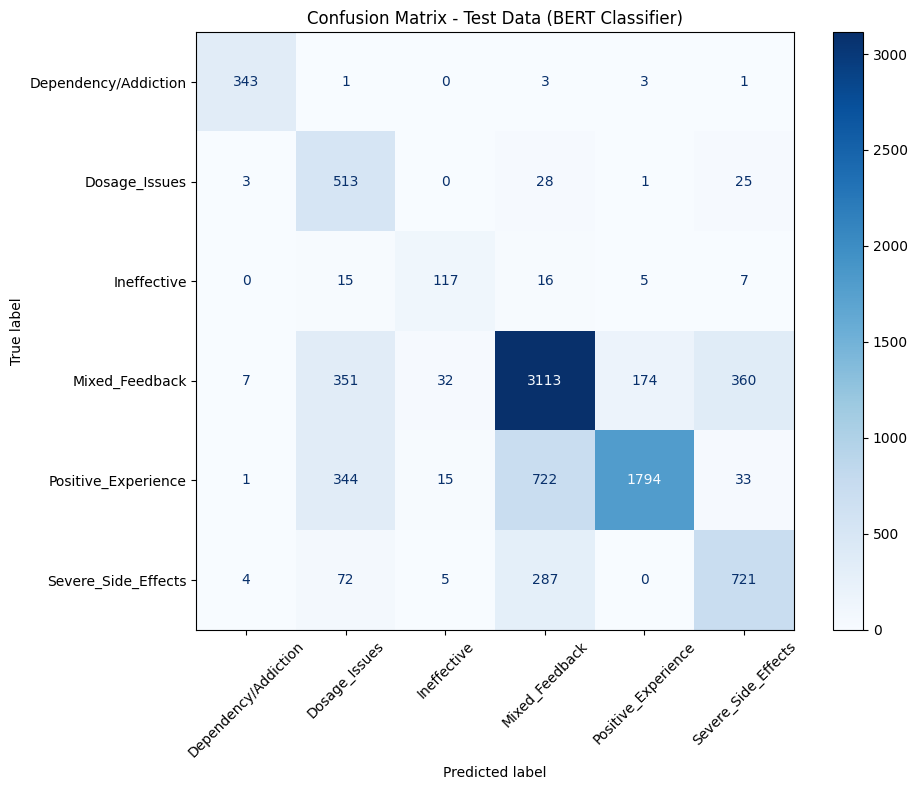


Classification Report - Test Data:
                      precision    recall  f1-score   support

Dependency/Addiction       0.96      0.98      0.97       351
       Dosage_Issues       0.40      0.90      0.55       570
         Ineffective       0.69      0.73      0.71       160
      Mixed_Feedback       0.75      0.77      0.76      4037
 Positive_Experience       0.91      0.62      0.73      2909
 Severe_Side_Effects       0.63      0.66      0.64      1089

            accuracy                           0.72      9116
           macro avg       0.72      0.78      0.73      9116
        weighted avg       0.77      0.72      0.73      9116



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import joblib
from torch.utils.data import DataLoader, TensorDataset

# 1. Load model and tokenizer
model_path = "./models/fine_tuned_distilbert_drug_reviews(1)"
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)
model.eval()

# Load the label encoder
label_encoder = joblib.load("./models/fine_tuned_distilbert_drug_reviews(1)/label_encoder.pkl")
class_names = label_encoder.classes_

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Prepare test data
# Use the test_texts and test_labels created in the previous subtask
texts = test_texts
true_labels = test_labels

# Tokenize test data
# This will still tokenize the whole set, but we will use a DataLoader for batching inference
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

# Create a TensorDataset and DataLoader for batch processing
test_dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'])
batch_size = 32 # Reduce batch size to avoid OOM errors
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)


# 3. Get predictions in batches
all_preds = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids, attention_mask = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

preds = np.array(all_preds)


# 4. Confusion matrix
print("Confusion Matrix - Test Data:")
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix - Test Data (BERT Classifier)")
plt.tight_layout()
plt.show()

# 5. Detailed report
print("\nClassification Report - Test Data:")
print(classification_report(true_labels, preds, target_names=class_names))

In [ ]:
# # The confusion matrix 'cm' and class names 'class_names' are already computed from the previous subtask.
# # We just need to visualize it again.
# import matplotlib.pyplot as plt
# from sklearn.metrics import ConfusionMatrixDisplay

# # Create a ConfusionMatrixDisplay object
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(10, 8)) # Adjust figure size as needed
# disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=ax)

# # Add title and ensure layout is tight
# plt.title("Confusion Matrix - Test Data (BERT Classifier)")
# plt.tight_layout()

# # Display the plot
# plt.show()

In [ ]:
%%writefile src/review_category.py
# src/review_category.py
import pandas as pd
# Import DistilBert specific classes
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
import joblib

# Load model and tokenizer
# Update model_path to the correct directory
model_path = "./models/fine_tuned_distilbert_drug_reviews(1)"
# Use DistilBertTokenizer and DistilBertForSequenceClassification
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)
# Load label encoder
label_encoder = joblib.load("./models/fine_tuned_distilbert_drug_reviews(1)/label_encoder.pkl")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set to evaluation mode

def predict_category(text):
    try:
        # Ensure input is string
        text = str(text)

        # Tokenize with truncation and padding
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,      # Truncates to max length
            padding=True,         # Pads to same length in batch
            max_length=512        # DistilBERT's max
        )

        # Move to device
        input_ids = inputs["input_ids"].to(device)
        attention_mask = inputs["attention_mask"].to(device)

        # Inference
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Get predicted class
        predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        predicted_label = label_encoder.inverse_transform(predictions)[0]

        return predicted_label

    except Exception as e:
        print(f"Error predicting for text: {text[:100]}... → {e}")
        return "Mixed_Feedback"  # Fallback category

def add_categories_to_data(input_csv, output_csv):
    df = pd.read_csv(input_csv)

    # Use 'review_text' as the standard column name if 'drug_review' or 'review' exists
    # Make sure to keep all other columns
    if 'drug_review' in df.columns:
        df.rename(columns={'drug_review': 'review_text'}, inplace=True)
    elif 'review' in df.columns and 'review_text' not in df.columns:
         df.rename(columns={'review': 'review_text'}, inplace=True)

    # Check if 'review_text' column exists after potential renaming
    if 'review_text' not in df.columns:
         raise ValueError("No review column found in CSV. Expected 'review_text', 'drug_review', or 'review'.")

    # Drop rows with missing review text before prediction
    df.dropna(subset=['review_text'], inplace=True)

    # Apply prediction and add 'predicted_category' as a new column
    # This will add the column to the existing DataFrame, keeping all other columns
    print("Applying BERT model to classify reviews...")
    df['predicted_category'] = df['review_text'].apply(predict_category)

    # Save result - all original columns plus 'predicted_category' will be saved
    df.to_csv(output_csv, index=False)
    print(f"Saved predictions to {output_csv}")
    return df

# Example usage (can be commented out if only modifying the file)
# if __name__ == "__main__":
#     # Update paths if needed
#     input_file = "/content/drug_reviews_clean_20250827_1521.csv" # Example input file name
#     output_file = "/content/drug_reviews_with_categories.csv"
#
#     # Check if the input file exists before trying to process
#     import os
#     if not os.path.exists(input_file):
#         print(f"Error: Input file not found at {input_file}")
#     else:
#         df = add_categories_to_data(input_file, output_file)
#         print("\nSample predictions:")
#         print(df[['review_text', 'predicted_category']].head())

Writing src/review_category.py


In [ ]:
from src.review_category import add_categories_to_data
import os

# Define input and output file paths
# Update input_file if your clean dataset has a different name or location
input_file = "src/data/combined_dataset.csv" # Corrected input file path
output_file = "/content/drug_reviews_with_categories.csv"

# Check if the input file exists before running the function
if not os.path.exists(input_file):
    print(f"Error: Input file not found at {input_file}")
else:
    print(f"Loading data from {input_file} and adding predicted categories...")
    df_with_categories = add_categories_to_data(input_file, output_file)
    print("\nSample of data with predicted categories:")
    display(df_with_categories.head())

Loading data from src/data/combined_dataset.csv and adding predicted categories...
Applying BERT model to classify reviews...
Saved predictions to /content/drug_reviews_with_categories.csv

Sample of data with predicted categories:


,drug_name,review_text,age,gender,predicted_category
0,metformin,I gained A LOT of weight and had unwanted hair...,73,Female,Mixed_Feedback
1,metformin,"""On Metformin for nearly two years. In Canadia...",80,Female,Dosage_Issues
2,metformin,Reviews and ratings for Metformin when used in...,52,Female,Mixed_Feedback
3,metformin,Reviews and ratings for Empagliflozin/metformi...,49,Female,Mixed_Feedback
4,metformin,Main side effect is extreme tiredness and fati...,47,Female,Severe_Side_Effects


In [ ]:
  # src/compute_trust_score.py
import pandas as pd
import os

# 1. Category → Score mapping (Refined Weights)
# Higher negative values for Severe Side Effects and Addiction
CATEGORY_SCORES = {
    "Positive_Experience": 1.0,
    "Mixed_Feedback": 0.0,
    "Dosage_Issues": -0.4,
    "Ineffective": -0.7,
    "Severe_Side_Effects": -0.9,
    "Dependency/Addiction": -1.0
}

def compute_trust_score(input_csv, output_csv="/content/trust_scores.csv"):
    """
    Computes trust scores for drugs based on all 6 BERT predicted categories.
    """
    try:
        if not os.path.exists(input_csv):
            print(f"Error: Input file not found at {input_csv}")
            return pd.DataFrame()

        df = pd.read_csv(input_csv)

        # Verify columns
        if 'predicted_category' not in df.columns or 'drug_name' not in df.columns:
            raise ValueError("Input CSV must contain 'predicted_category' and 'drug_name' columns.")

        # Map categories to numerical scores
        df['category_score'] = df['predicted_category'].map(CATEGORY_SCORES)

        # Handle any categories that might not be in the dictionary
        df = df.dropna(subset=['category_score'])

        # 2. Group by drug_name and aggregate ALL categories
        summary = df.groupby('drug_name').agg(
            avg_raw_score=('category_score', 'mean'),
            total_reviews=('category_score', 'size'),
            # Counts for every single category
            positive_count=('predicted_category', lambda x: (x == "Positive_Experience").sum()),
            mixed_count=('predicted_category', lambda x: (x == "Mixed_Feedback").sum()),
            dosage_count=('predicted_category', lambda x: (x == "Dosage_Issues").sum()),
            ineffective_count=('predicted_category', lambda x: (x == "Ineffective").sum()),
            side_effect_count=('predicted_category', lambda x: (x == "Severe_Side_Effects").sum()),
            dependency_count=('predicted_category', lambda x: (x == "Dependency/Addiction").sum())
        ).reset_index()

        # 3. Normalize Trust Score to 0–1 scale
        # Formula: (mean_score + 1) / 2
        summary['trust_score'] = (summary['avg_raw_score'] + 1) / 2

        # Round for readability
        summary['trust_score'] = summary['trust_score'].round(3)

        # 4. Add a Safety Label based on the score
        def get_safety_label(score):
            if score >= 0.8: return "Highly Trusted"
            if score >= 0.6: return "Generally Safe"
            if score >= 0.4: return "Mixed/Caution"
            return "High Risk"

        summary['safety_status'] = summary['trust_score'].apply(get_safety_label)

        # Sort by trust score (highest first)
        summary = summary.sort_values('trust_score', ascending=False)

        # Save result
        summary.to_csv(output_csv, index=False)
        print(f"Success! Trust scores for {len(summary)} drugs saved to {output_csv}")

        return summary

    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

# -----------------------------
# AUTO-EXECUTE (If run as main script)
# -----------------------------
if __name__ == "__main__":
    # This assumes your inference script saved the results here
    INPUT = "/content/drug_reviews_with_categories.csv"
    OUTPUT = "/content/drug_trust_summary.csv"

    result = compute_trust_score(INPUT, OUTPUT)
    if not result.empty:
        print("\n--- TOP 5 TRUSTED DRUGS ---")
        print(result[['drug_name', 'trust_score', 'safety_status', 'total_reviews']].head())

        print("\n--- BOTTOM 5 RISKIE DRUGS ---")
        print(result[['drug_name', 'trust_score', 'safety_status', 'total_reviews']].tail())

Success! Trust scores for 2559 drugs saved to /content/drug_trust_summary.csv

--- TOP 5 TRUSTED DRUGS ---
                             drug_name  trust_score   safety_status  \
1637                       nicotrol ns          1.0  Highly Trusted   
1648                        nizatidine          1.0  Highly Trusted   
1646            nitrolingual pumpspray          1.0  Highly Trusted   
1683                            nystop          1.0  Highly Trusted   
72    acetaminophen / chlorpheniramine          1.0  Highly Trusted   

      total_reviews  
1637              1  
1648              1  
1646              2  
1683              1  
72                1  

--- BOTTOM 5 RISKIE DRUGS ---
         drug_name  trust_score safety_status  total_reviews
405   brivaracetam          0.0     High Risk              1
1987         revia          0.0     High Risk              1
55         abstral          0.0     High Risk              1
920       ethotoin          0.0     High Risk              

In [ ]:
# #run this locally :
# import streamlit as st
# import pandas as pd
# import plotly.express as px
# import os

# # -----------------------------
# # Paths
# # -----------------------------
# DATA_PATH = r"drug_reviews_with_categories (1).csv"
# TRUST_SCORES_PATH = r"trust_scores.csv"

# # -----------------------------
# # File Validation
# # -----------------------------
# if not os.path.exists(DATA_PATH):
#     st.error(f"Data file not found: {DATA_PATH}")
#     st.stop()

# if not os.path.exists(TRUST_SCORES_PATH):
#     st.warning(f"⚠️ Trust scores file not found: {TRUST_SCORES_PATH}")
#     st.info("Using live computation from reviews.")
#     TRUST_SCORES_PATH = None

# # -----------------------------
# # Data Loaders
# # -----------------------------
# @st.cache_data
# def load_data():
#     try:
#         df = pd.read_csv(DATA_PATH)
#         if 'drug_review' in df.columns:
#             df.rename(columns={'drug_review': 'review_text'}, inplace=True)
#         if 'drug_name' not in df.columns:
#             st.error("❌ 'drug_name' column missing in data")
#             st.stop()
#         df['drug_name'] = df['drug_name'].str.lower().str.strip()
#         df['predicted_category'] = df['predicted_category'].astype(str).str.strip()
#         return df
#     except Exception as e:
#         st.error(f"❌ Failed to load data: {str(e)}")
#         st.stop()

# @st.cache_data
# def load_trust_scores():
#     if TRUST_SCORES_PATH and os.path.exists(TRUST_SCORES_PATH):
#         trust_df = pd.read_csv(TRUST_SCORES_PATH)
#         trust_df['drug_name'] = trust_df['drug_name'].str.lower().str.strip()
#         trust_df = trust_df.groupby('drug_name', as_index=False)['trust_score'].mean()
#         return trust_df.set_index('drug_name')['trust_score']
#     else:
#         df = load_data()
#         category_scores = {
#             "Positive_Experience": +1.0,
#             "Severe_Side_Effects": -1.0,
#             "Ineffective": -0.8,
#             "Dependency/Addiction": -0.9,
#             "Dosage_Issues": -0.5,
#             "Mixed_Feedback": 0.0
#         }
#         df['score'] = df['predicted_category'].map(category_scores)
#         trust_scores = df.groupby('drug_name')['score'].mean()
#         trust_scores = (trust_scores + 1) / 2
#         return trust_scores.fillna(0.0)

# df = load_data()
# trust_scores = load_trust_scores()

# # -----------------------------
# # Main Tabs
# # -----------------------------
# main_tab1, main_tab2 = st.tabs(["📈 Overview Dashboard", "💊 Drug Explorer"])

# # ==========================================================
# # TAB 1 — OVERVIEW DASHBOARD
# # ==========================================================
# with main_tab1:
#     st.title("💊 DrugTrust AI Dashboard")
#     st.markdown("#### AI-powered insights from real patient reviews")

#     # Overall Summary
#     avg_trust = round(trust_scores.mean(), 2)
#     num_drugs = len(trust_scores)
#     total_reviews = len(df)

#     col1, col2, col3 = st.columns(3)
#     col1.metric("Avg Trust Score", f"{avg_trust:.2f}")
#     col2.metric("Unique Drugs", num_drugs)
#     col3.metric("Total Reviews", total_reviews)

#     # Category Distribution
#     cat_counts = df['predicted_category'].value_counts().reset_index()
#     cat_counts.columns = ['Category', 'Count']
#     fig1 = px.pie(
#         cat_counts,
#         values='Count',
#         names='Category',
#         title="Overall Review Categories",
#         color='Category',
#         color_discrete_map={
#             "Positive_Experience": "#4CAF50",
#             "Severe_Side_Effects": "#E53935",
#             "Mixed_Feedback": "#FFB300",
#             "Ineffective": "#9E9E9E",
#             "Dosage_Issues": "#2196F3",
#             "Dependency/Addiction": "#9C27B0",
#         }
#     )
#     st.plotly_chart(fig1, use_container_width=True)

#     # Trust Score Leaderboard
#     st.markdown("### 🏆 Top 20 Drugs by Trust Score")
#     top20 = trust_scores.sort_values(ascending=False).head(20)
#     fig2 = px.bar(
#         x=top20.index,
#         y=top20.values,
#         labels={"x": "Drug", "y": "Trust Score"},
#         title="Top Drugs by Average Trust",
#         color=top20.values,
#         color_continuous_scale="Blues"
#     )
#     st.plotly_chart(fig2, use_container_width=True)

#     # Age distribution overall
#     if 'age' in df.columns and df['age'].notna().any():
#         st.markdown("### 👥 Reviewer Age Distribution")
#         fig3 = px.histogram(df, x='age', nbins=15, title="Age Distribution of Reviewers")
#         st.plotly_chart(fig3, use_container_width=True)

# # ==========================================================
# # TAB 2 — DRUG EXPLORER
# # ==========================================================
# with main_tab2:
#     st.title("🔍 Drug Explorer")
#     st.markdown("Filter and analyze reviews for specific drugs and demographics.")

#     # -----------------------------
#     # Sidebar Filters
#     # -----------------------------
#     st.sidebar.header("🧩 Filters")

#     # Trust score filter
#     min_trust = st.sidebar.slider("🏆 Min Trust Score", 0.0, 1.0, 0.0, 0.05)
#     available_drugs = trust_scores[trust_scores >= min_trust].index.tolist()
#     available_drugs = sorted(set(available_drugs) & set(df['drug_name'].unique()))

#     if not available_drugs:
#         st.warning("⚠️ No drugs meet the minimum trust threshold.")
#         st.stop()

#     selected_drug = st.sidebar.selectbox("💊 Select Drug", available_drugs)

#     # Age Filter
#     if 'age' in df.columns:
#         min_age = int(df['age'].min()) if df['age'].notna().any() else 10
#         max_age = int(df['age'].max()) if df['age'].notna().any() else 100
#         age_range = st.sidebar.slider("📅 Age Range", min_age, max_age, (18, 70))
#     else:
#         age_range = (0, 120)

#     # Gender Filter
#     gender_filter = st.sidebar.selectbox("👤 Gender", ["All", "male", "female"])

#     # Optional Weight Filter
#     if 'weight' in df.columns:
#         min_w, max_w = int(df['weight'].min()), int(df['weight'].max())
#         weight_range = st.sidebar.slider("⚖️ Weight Range (kg)", min_w, max_w, (min_w, max_w))
#     else:
#         weight_range = None

#     # -----------------------------
#     # Apply Filters
#     # -----------------------------
#     filtered_df = df[df['drug_name'] == selected_drug]

#     # Age
#     if 'age' in filtered_df.columns:
#         age_mask = filtered_df['age'].isna() | (
#             (filtered_df['age'] >= age_range[0]) & (filtered_df['age'] <= age_range[1])
#         )
#         filtered_df = filtered_df[age_mask]

#     # Gender
#     if gender_filter != "All" and 'gender' in filtered_df.columns:
#         gender_mask = filtered_df['gender'].isna() | (filtered_df['gender'] == gender_filter)
#         filtered_df = filtered_df[gender_mask]

#     # Weight
#     if weight_range and 'weight' in filtered_df.columns:
#         weight_mask = filtered_df['weight'].isna() | (
#             (filtered_df['weight'] >= weight_range[0]) & (filtered_df['weight'] <= weight_range[1])
#         )
#         filtered_df = filtered_df[weight_mask]

#     # -----------------------------
#     # Metrics and Data Display
#     # -----------------------------
#     current_trust = trust_scores.get(selected_drug, 0.0)
#     if isinstance(current_trust, pd.Series):
#         current_trust = current_trust.iloc[0]

#     st.subheader(f"📊 {selected_drug.capitalize()} — Trust & Review Insights")
#     st.metric("Trust Score", f"{float(current_trust):.2f}")

#     if len(filtered_df) == 0:
#         st.info("ℹ️ No reviews match the current filters. Try adjusting age/gender/weight.")
#         st.stop()

#     total = len(filtered_df)
#     pos = len(filtered_df[filtered_df['predicted_category'] == "Positive_Experience"])
#     neg = len(filtered_df[filtered_df['predicted_category'] == "Severe_Side_Effects"])
#     mixed = len(filtered_df[filtered_df['predicted_category'] == "Mixed_Feedback"])

#     col1, col2, col3, col4 = st.columns(4)
#     col1.metric("Total Reviews", total)
#     col2.metric("Positive", pos)
#     col3.metric("Side Effects", neg)
#     col4.metric("Mixed", mixed)

#     # Tabs within explorer
#     subtab1, subtab2, subtab3, subtab4 = st.tabs([
#         "📈 Overview", "✅ Positive Effects", "⚠️ Side Effects", "🔄 Mixed Feedback"
#     ])

#     with subtab1:
#         cat_counts = filtered_df['predicted_category'].value_counts().reset_index()
#         cat_counts.columns = ['Category', 'Count']
#         fig1 = px.pie(
#             cat_counts,
#             values='Count',
#             names='Category',
#             title="Review Category Breakdown",
#             color='Category',
#             color_discrete_map={
#                 "Positive_Experience": "#4CAF50",
#                 "Severe_Side_Effects": "#E53935",
#                 "Mixed_Feedback": "#FFB300"
#             }
#         )
#         st.plotly_chart(fig1, use_container_width=True)

#         if 'age' in filtered_df.columns and filtered_df['age'].notna().any():
#             fig2 = px.histogram(filtered_df, x='age', nbins=10, title="Reviewer Age Distribution")
#             st.plotly_chart(fig2, use_container_width=True)

#     # Subtab: Positive
#     with subtab2:
#         pos_reviews = filtered_df[filtered_df['predicted_category'] == "Positive_Experience"]
#         if len(pos_reviews) == 0:
#             st.info("No positive reviews match the filters.")
#         else:
#             for _, row in pos_reviews.iterrows():
#                 with st.expander(f"💬 {row['review_text'][:80]}..."):
#                     st.write(row['review_text'])
#                     #st.caption(f"👤 {row.get('gender','Unknown')}, {row.get('age','Unknown')} yrs")

#     # Subtab: Side Effects
#     with subtab3:
#         neg_reviews = filtered_df[filtered_df['predicted_category'] == "Severe_Side_Effects"]
#         if len(neg_reviews) == 0:
#             st.info("No severe side effects reported.")
#         else:
#             for _, row in neg_reviews.iterrows():
#                 with st.expander(f"⚠️ {row['review_text'][:80]}..."):
#                     st.write(row['review_text'])
#                     #st.caption(f"👤 {row.get('gender','Unknown')}, {row.get('age','Unknown')} yrs")

#     # Subtab: Mixed Feedback
#     with subtab4:
#         mixed_reviews = filtered_df[filtered_df['predicted_category'] == "Mixed_Feedback"]
#         if len(mixed_reviews) == 0:
#             st.info("No mixed feedback found.")
#         else:
#             for _, row in mixed_reviews.iterrows():
#                 with st.expander(f"🔄 {row['review_text'][:80]}..."):
#                     st.write(row['review_text'])
#                     #st.caption(f"👤 {row.get('gender','Unknown')}, {row.get('age','Unknown')} yrs")


In [ ]:
!pip install streamlit plotly pyngrok

In [ ]:
# bert_classifier.py
import os
import pandas as pd
import numpy as np
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
import joblib

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
# Update path as needed
df = pd.read_csv("/content/src/data/combined_dataset.csv")  # Ensure this file exists

# Rename column if needed
if 'review' in df.columns:
    df = df.rename(columns={'review': 'review_text'})

# Drop rows with missing review text
df = df.dropna(subset=['review_text'])

# Define categories
categories = [
    "Positive_Experience",
    "Severe_Side_Effects",
    "Ineffective",
    "Dependency/Addiction",
    "Dosage_Issues",
    "Mixed_Feedback"
]

# Simple rule-based labeling
def classify_review_category(text):
    text = text.lower()

    # Positive experience keywords
    positive_kw = [
        'helped', 'working', 'works', 'effective', 'relief', 'improved',
        'better', 'stable', 'great', 'miracle', 'useful', 'fantastic',
        'life changing', 'good', 'happy'
    ]

    # Ineffective keywords
    ineffective_kw = [
        'not work', 'no effect', 'didn’t help', 'did not help', 'useless',
        'ineffective', 'zero improvement', 'made no difference'
    ]

    # Dependency keywords
    dependency_kw = [
        'addicted', 'addiction', 'dependence', 'dependent', 'craving',
        'withdrawal', 'can’t stop', 'hard to stop', 'habit forming'
    ]

    # Dosage issues keywords
    dosage_kw = [
        'dosage', 'dose', 'too strong', 'too weak', 'high dose', 'low dose',
        'adjust dose', 'missed dose'
    ]

    # Severe side effects keywords
    side_effect_kw = [
        'nausea', 'vomit', 'dizzy', 'dizziness', 'tired', 'insomnia', 'panic',
        'rash', 'weight gain', 'weight loss', 'heart racing', 'palpitations',
        'sweat', 'shaking', 'agitation', 'confusion'
    ]

    # 1) Dependency / addiction (highest priority)
    if any(k in text for k in dependency_kw):
        return "Dependency/Addiction"

    # 2) Severe side effects
    if any(k in text for k in side_effect_kw):
        # If it also works but has side effects → Mixed feedback
        if any(k in text for k in positive_kw):
            return "Mixed_Feedback"
        return "Severe_Side_Effects"

    # 3) Dosage problems
    if any(k in text for k in dosage_kw):
        return "Dosage_Issues"

    # 4) Ineffective
    if any(k in text for k in ineffective_kw):
        return "Ineffective"

    # 5) Positive experience
    if any(k in text for k in positive_kw):
        return "Positive_Experience"

    # 6) Default fallback
    return "Mixed_Feedback"

# Apply labeling
df['review_category'] = df['review_text'].apply(classify_review_category)

# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['review_category'])

# Train-test split (first split: train vs validation+test)
train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
    df['review_text'].tolist(),
    df['label'].tolist(),
    test_size=0.4, # Allocate 40% for combined validation and test
    random_state=42,
    stratify=df['label']
)

# Second split (validation vs test)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    val_test_texts,
    val_test_labels,
    test_size=0.5, # Split the 40% equally: 20% validation, 20% test
    random_state=42,
    stratify=val_test_labels
)

# -----------------------------
# 2. Tokenizer & Model
# -----------------------------
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ReviewDataset(train_texts, train_labels, tokenizer)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer)
# Note: A test_dataset is not strictly needed for training, but the test_texts and test_labels are now available for later evaluation.


# Load model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_encoder.classes_)
)

# -----------------------------
# 3. Compute Metrics (Fix for eval_accuracy)
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

# -----------------------------
# 4. Training Arguments
# -----------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",           # Evaluates at the end of each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",  # Now works because we define it
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=10,
    report_to="none",                # Disable external logging (WandB, etc.)
    fp16=True,                       # Use mixed precision for speed (if GPU)
    remove_unused_columns=False      # Helps avoid some model errors
)

# -----------------------------
# 5. Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics   # Critical: This fixes the KeyError
)

# -----------------------------
# 6. Train the Model
# -----------------------------
print("Starting training...")
trainer.train()

# -----------------------------
# 7. Save Model & Label Encoder
# -----------------------------

MODEL_OUTPUT_DIR = "./models/fine_tuned_distilbert_drug_reviews"
print("Training complete. Saving model and tokenizer...")

# Use the Trainer's dedicated save method
trainer.save_model(MODEL_OUTPUT_DIR)

# Ensure the tokenizer files are also saved (though save_model often handles this)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

# Save the label encoder separately
joblib.dump(label_encoder, f"{MODEL_OUTPUT_DIR}/label_encoder.pkl")

print(f"BERT model trained and saved successfully to: {MODEL_OUTPUT_DIR}")
print(f"Check the contents of this folder: {os.listdir(MODEL_OUTPUT_DIR)}") # New Debug Line!

# print("Training complete. Saving model...")
# model.save_pretrained("./models/fine_tuned_distilbert_drug_reviews")
# tokenizer.save_pretrained("./models/fine_tuned_distilbert_drug_reviews")
# joblib.dump(label_encoder, "./models/label_encoder.pkl")

# print("BERT model trained and saved successfully!")
# print("Model: ./models/fine_tuned_distilbert_drug_reviews")
# print("Label Encoder: ./models/label_encoder.pkl")

# Now the test_texts and test_labels are available for later evaluation

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.092900,0.072287,0.988262
2,0.038100,0.042634,0.993528
3,0.047600,0.033324,0.995502
4,0.000900,0.015699,0.997916
5,0.000400,0.017742,0.997806


Training complete. Saving model and tokenizer...
BERT model trained and saved successfully to: ./models/fine_tuned_distilbert_drug_reviews
Check the contents of this folder: ['vocab.txt', 'special_tokens_map.json', 'model.safetensors', 'config.json', 'label_encoder.pkl', 'training_args.bin', 'tokenizer_config.json']


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import joblib
from torch import nn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
df = pd.read_csv("/content/src/data/combined_dataset.csv")
if 'review' in df.columns:
    df = df.rename(columns={'review': 'review_text'})

df = df.dropna(subset=['review_text'])

def classify_review_category(text):
    # FIX 1: Normalize text (handles the apostrophe issue)
    text = text.lower().replace("’", "'")

    # FIX 2: Expanded keywords for better coverage
    positive_kw = ['helped', 'working', 'effective', 'relief', 'improved', 'better', 'great', 'life changing']
    ineffective_kw = ['not work', 'no effect', 'useless', 'ineffective', 'waste of money', 'nothing happened', 'did nothing']
    dependency_kw = ['addicted', 'withdrawal', 'can\'t stop', 'dependent', 'shakes', 'craving']
    dosage_kw = ['dosage', 'dose', 'too strong', 'too weak', '10mg', '20mg', '50mg', '100mg', 'mg']
    side_effect_kw = ['nausea', 'vomit', 'dizzy', 'rash', 'insomnia', 'headache', 'tired']

    if any(k in text for k in dependency_kw): return "Dependency/Addiction"
    if any(k in text for k in side_effect_kw):
        if any(k in text for k in positive_kw): return "Mixed_Feedback"
        return "Severe_Side_Effects"
    if any(k in text for k in dosage_kw): return "Dosage_Issues"
    if any(k in text for k in ineffective_kw): return "Ineffective"
    if any(k in text for k in positive_kw): return "Positive_Experience"

    return "Mixed_Feedback"

df['review_category'] = df['review_text'].apply(classify_review_category)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['review_category'])

# Split data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['review_text'].tolist(), df['label'].tolist(), test_size=0.2, stratify=df['label'], random_state=42
)

# -----------------------------
# 2. Weighted Loss Logic (The "Black Thing")
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Calculate weights to stop the model from favoring "Mixed_Feedback"
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Apply the weights here
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# -----------------------------
# 3. Model & Dataset Setup
# -----------------------------
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ReviewDataset(train_texts, train_labels, tokenizer)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=len(label_encoder.classes_)
).to(device)

# -----------------------------
# 4. Training
# -----------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True if torch.cuda.is_available() else False,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return {"accuracy": (np.argmax(logits, axis=-1) == labels).mean()}

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Starting improved training...")
trainer.train()

# Save everything
MODEL_DIR = "./models/fine_tuned_distilbert_drug_reviews(1)"
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
joblib.dump(label_encoder, f"{MODEL_DIR}/label_encoder.pkl")
print("Done!")

KeyboardInterrupt: 

In [ ]:
!zip -r "/content/models/fine_tuned_distilbert_drug_reviews(1).zip" "/content/models/fine_tuned_distilbert_drug_reviews(1)"

from google.colab import files
files.download("/content/models/fine_tuned_distilbert_drug_reviews(1).zip")

  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/ (stored 0%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/vocab.txt (deflated 53%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/special_tokens_map.json (deflated 42%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/model.safetensors (deflated 8%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/config.json (deflated 52%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/label_encoder.pkl (deflated 33%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/training_args.bin (deflated 54%)
  adding: content/models/fine_tuned_distilbert_drug_reviews(1)/tokenizer_config.json (deflated 75%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>